# Data Wrangling in Python - Chapter 4

## Which avocado size is most popular?
Avocados are increasingly popular and delicious in guacamole and on toast. The Hass Avocado Board keeps track of avocado supply and demand across the USA, including the sales of three different sizes of avocado. In this exercise, you'll use a bar plot to figure out which size is the most popular.

Bar plots are great for revealing relationships between categorical (size) and numeric (number sold) variables, but you'll often have to manipulate your data first in order to get the numbers you need for plotting.

pandas has been imported as pd, import avoplotto.pkl as avocados

Print the head of the avocados dataset. What columns are available?\
For each avocado size group, calculate the total number sold, storing as nb_sold_by_size.
Create a bar plot of the number of avocados sold by size.\
Show the plot.

         date          type  year  avg_price   size     nb_sold
0  2015-12-27  conventional  2015       0.95  small  9626901.09
1  2015-12-20  conventional  2015       0.98  small  8710021.76
2  2015-12-13  conventional  2015       0.93  small  9855053.66
3  2015-12-06  conventional  2015       0.89  small  9405464.36
4  2015-11-29  conventional  2015       0.99  small  8094803.56


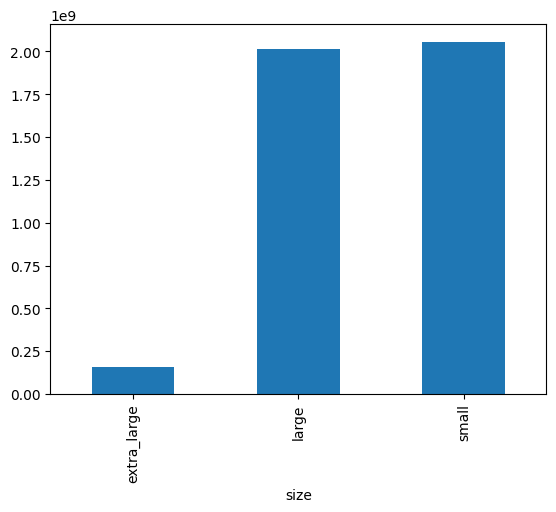

In [2]:
# Import matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt
import pandas as pd

# Look at the first few rows of data
avocados = pd.read_pickle("avoplotto.pkl")
print(avocados.head())

# Get the total number of avocados sold of each size
nb_sold_by_size = avocados.groupby("size")["nb_sold"].sum()

# Create a bar plot of the number of avocados sold by size
nb_sold_by_size.plot(kind="bar")

# Show the plot
plt.show()

## Changes in sales over time
Line plots are designed to visualize the relationship between two numeric variables, where each data values is connected to the next one. They are especially useful for visualizing the change in a number over time since each time point is naturally connected to the next time point. In this exercise, you'll visualize the change in avocado sales over three years.

pandas has been imported as pd, and avocados is available.

Get the total number of avocados sold on each date. The DataFrame has two rows for each date—one for organic, and one for conventional. Save this as nb_sold_by_date.\
Create a line plot of the number of avocados sold.\
Show the plot.

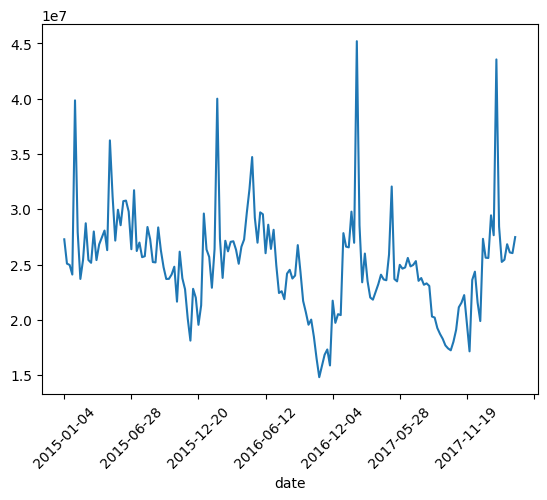

In [3]:
# Import matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt

# Get the total number of avocados sold on each date
nb_sold_by_date = avocados.groupby("date")["nb_sold"].sum()

# Create a line plot of the number of avocados sold by date
nb_sold_by_date.plot(kind="line", rot=45)

# Show the plot
plt.show()

## Avocado supply and demand
Scatter plots are ideal for visualizing relationships between numerical variables. In this exercise, you'll compare the number of avocados sold to average price and see if they're at all related. If they're related, you may be able to use one number to predict the other.

matplotlib.pyplot has been imported as plt, pandas has been imported as pd, and avocados is available.

Create a scatter plot with nb_sold on the x-axis and avg_price on the y-axis. Title it "Number of avocados sold vs. average price".\
Show the plot.

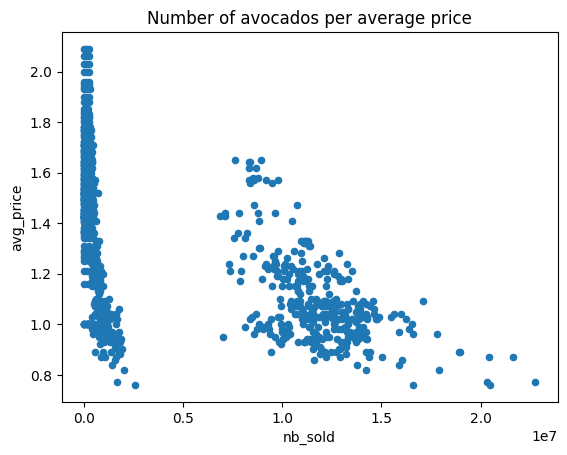

In [4]:
# Scatter plot of avg_price vs. nb_sold with title
avocados.plot(x="nb_sold", y="avg_price", kind="scatter", title="Number of avocados per average price")

# Show the plot
plt.show()

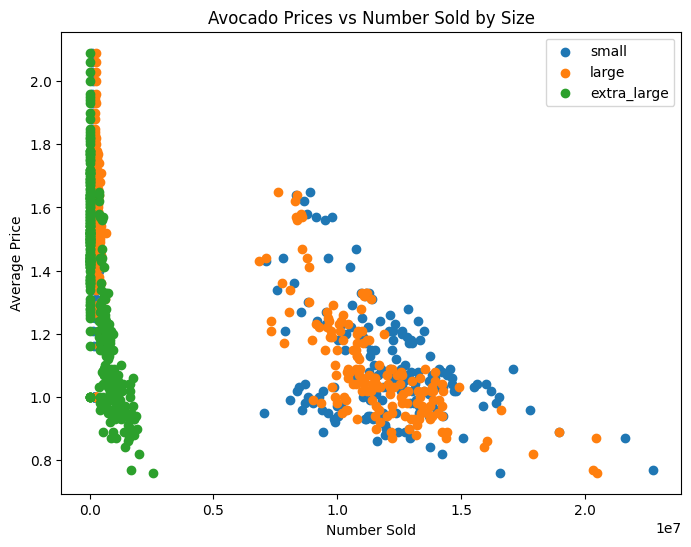

In [5]:
sizes = avocados['size'].unique()

plt.figure(figsize=(8, 6))

for t in sizes:
    subset = avocados[avocados['size'] == t]
    plt.scatter(subset['nb_sold'], subset['avg_price'], label=t)

plt.xlabel("Number Sold")
plt.ylabel("Average Price")
plt.title("Avocado Prices vs Number Sold by Size")
plt.legend()
plt.show()

<positron-console-cell-6>:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


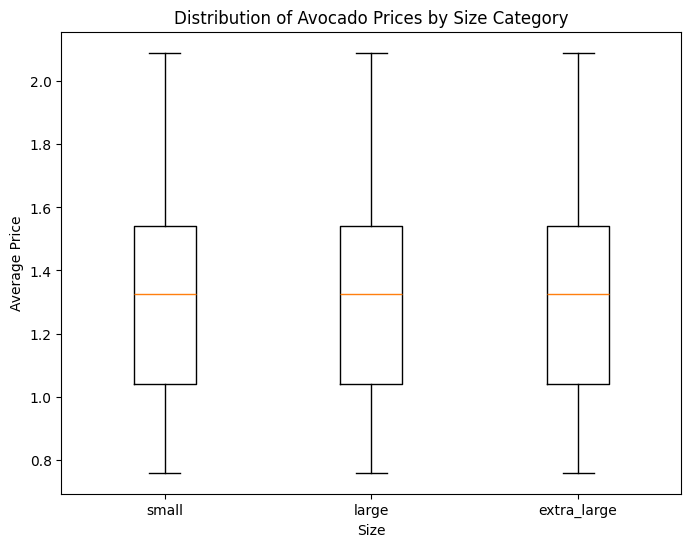

In [6]:
sizes = avocados['size'].unique()

# Prepare data for boxplot
data = [avocados[avocados['size'] == s]['avg_price'] for s in sizes]

plt.figure(figsize=(8, 6))

# Create boxplot
plt.boxplot(data, labels=sizes)

plt.xlabel("Size")
plt.ylabel("Average Price")
plt.title("Distribution of Avocado Prices by Size Category")
plt.show()

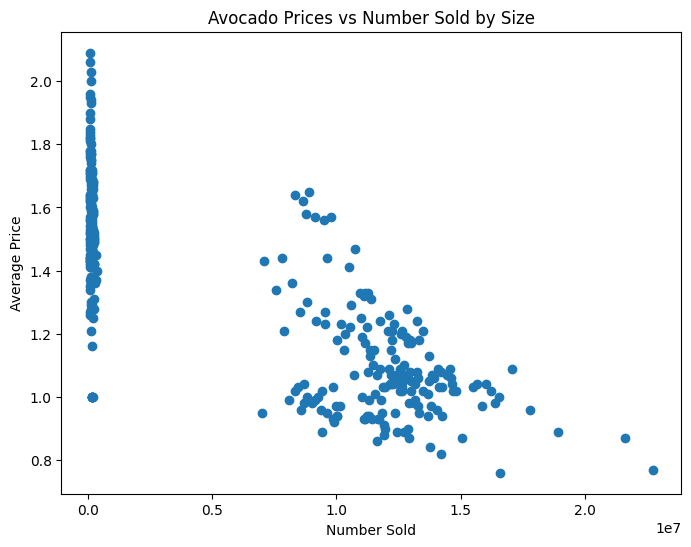

In [15]:
plt.figure(figsize=(8, 6))
subset = avocados[avocados['size'] == 'small']
plt.scatter(subset['nb_sold'], subset['avg_price'], label=t)

plt.xlabel("Number Sold")
plt.ylabel("Average Price")
plt.title("Avocado Prices vs Number Sold by Size")
# plt.legend()
plt.show()

## Price of conventional vs. organic avocados
Creating multiple plots for different subsets of data allows you to compare groups. In this exercise, you'll create multiple histograms to compare the prices of conventional and organic avocados.

matplotlib.pyplot has been imported as plt and pandas has been imported as pd.

Subset avocados for the "conventional" type and create a histogram of the avg_price column.\
Create a histogram of avg_price for "organic" type avocados.\
Add a legend to your plot, with the names "conventional" and "organic".\
Show your plot.

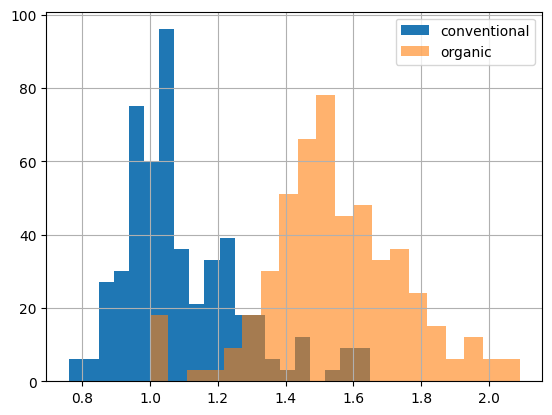

In [7]:
# Histogram of conventional avg_price 
avocados[avocados["type"]=="conventional"]["avg_price"].hist(bins=20)
# alternative (with plt.show()): avocados[avocados["type"]=="conventional"]["avg_price"].plot(kind="hist")

# Histogram of organic avg_price
avocados[avocados["type"]=="organic"]["avg_price"].hist(alpha=0.6, bins=20)

# Add a legend
plt.legend(["conventional", "organic"])

# Show the plot
# plt.show()

## Finding missing values
Missing values are everywhere, and you don't want them interfering with your work. Some functions ignore missing data by default, but that's not always the behavior you might want. Some functions can't handle missing values at all, so these values need to be taken care of before you can use them. If you don't know where your missing values are, or if they exist, you could make mistakes in your analysis. In this exercise, you'll determine if there are missing values in the dataset, and if so, how many.

pandas has been imported as pd and avocados_2016, a subset of avocados that contains only sales from 2016, is available.

Print a DataFrame that shows whether each value in avocados_2016 is missing or not.\
Print a summary that shows whether any value in each column is missing or not.\
Create a bar plot of the total number of missing values in each column.

date               False
avg_price          False
total_sold         False
small_sold          True
large_sold          True
xl_sold             True
total_bags_sold    False
small_bags_sold    False
large_bags_sold    False
xl_bags_sold       False
dtype: bool
date               0
avg_price          0
total_sold         0
small_sold         6
large_sold         6
xl_sold            4
total_bags_sold    0
small_bags_sold    0
large_bags_sold    0
xl_bags_sold       0
dtype: int64


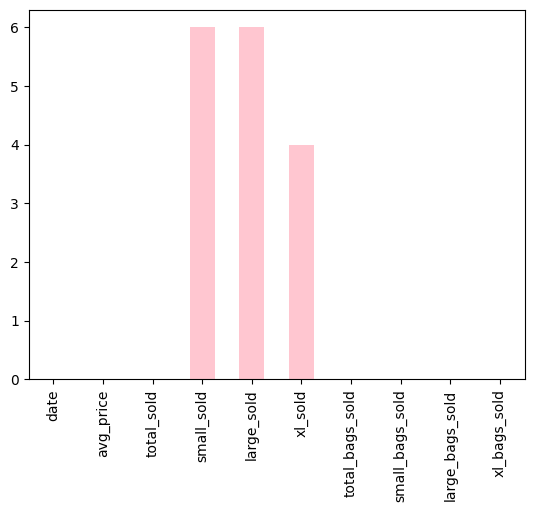

In [8]:
# Import matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt


avocados_2016 = pd.read_csv("avocados_2016.csv")
# Check individual values for missing values
print(avocados_2016.isna().any())

# Check each column for missing values
print(avocados_2016.isna().sum())

# Bar plot of missing values by variable
avocados_2016.isna().sum().plot(kind="bar", color="pink", alpha=0.9)

# Show plot
plt.show()

## Removing missing values
Now that you know there are some missing values in your DataFrame, you have a few options to deal with them. One way is to remove them from the dataset completely. In this exercise, you'll remove missing values by removing all rows that contain missing values.

pandas has been imported as pd and avocados_2016 is available.

Remove the rows of avocados_2016 that contain missing values and store the remaining rows in avocados_complete.\
Verify that all missing values have been removed from avocados_complete. Calculate each column that has NAs and print.

In [9]:
# Remove rows with missing values
avocados_complete = avocados_2016.dropna()

# Check if any columns contain missing values
print(avocados_complete.isna().any())

date               False
avg_price          False
total_sold         False
small_sold         False
large_sold         False
xl_sold            False
total_bags_sold    False
small_bags_sold    False
large_bags_sold    False
xl_bags_sold       False
dtype: bool


## Replacing missing values
Another way of handling missing values is to replace them all with the same value. For numerical variables, one option is to replace values with 0— you'll do this here. However, when you replace missing values, you make assumptions about what a missing value means. In this case, you will assume that a missing number sold means that no sales for that avocado type were made that week.

In this exercise, you'll see how replacing missing values can affect the distribution of a variable using histograms. You can plot histograms for multiple variables at a time as follows:

dogs[["height_cm", "weight_kg"]].hist()
pandas has been imported as pd and matplotlib.pyplot has been imported as plt. The avocados_2016 dataset is available.

A list has been created, cols_with_missing, containing the names of columns with missing values: "small_sold", "large_sold", and "xl_sold".\
Create a histogram of those columns.\
Show the plot.

Look at the second instruction too!

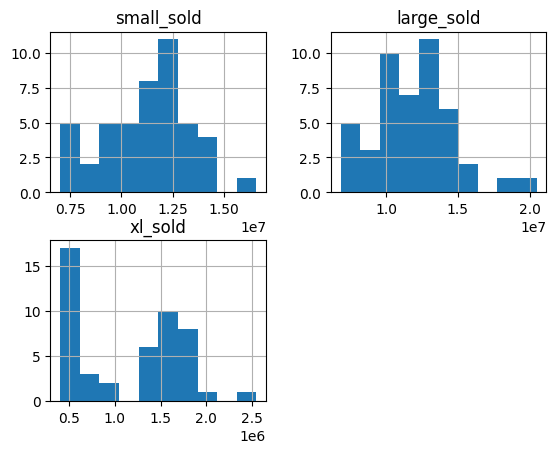

In [10]:
# List the columns with missing values
cols_with_missing = ["small_sold", "large_sold", "xl_sold"]

# Create histograms showing the distributions cols_with_missing
avocados_2016[cols_with_missing].hist()

# Show the plot
plt.show()

# x-axis values are times 1e7 (i.e. till 20 millions)

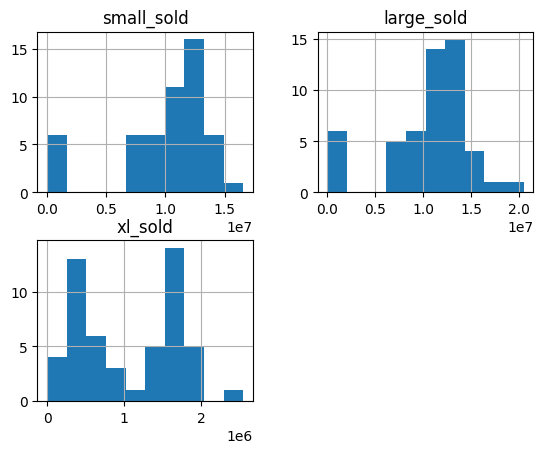

In [11]:
# Fill in missing values with 0
avocados_filled = avocados_2016.fillna(0)

# Create histograms of the filled columns
avocados_filled[cols_with_missing].hist()

plt.show()

In [12]:
# Create a list of dictionaries with new data
avocados_list = [
    {"date": "2019-11-03", "small_sold": 10376832, "large_sold": 7835071},
    {"date": "2019-11-10", "small_sold": 10717154, "large_sold": 8561348}
]

# Convert list into DataFrame
avocados_2019 = pd.DataFrame(avocados_list)

# Print the new DataFrame
print(avocados_2019)

         date  small_sold  large_sold
0  2019-11-03    10376832     7835071
1  2019-11-10    10717154     8561348


In [13]:
# Create a dictionary of lists with new data
avocados_dict = {
    "date": ["2019-11-17", "2019-12-01"],
    "small_sold": [10859987, 9291631],
    "large_sold": [7674135, 6238096]
}

# Convert dictionary into DataFrame
avocados_2019 = pd.DataFrame(avocados_dict)

# Print the new DataFrame
print(avocados_2019)

         date  small_sold  large_sold
0  2019-11-17    10859987     7674135
1  2019-12-01     9291631     6238096


In [14]:
airline_bumping = pd.read_csv("airline_bumping.csv")

# Take a look at the DataFrame
print(airline_bumping.head())

# For each airline, select nb_bumped and total_passengers and sum
airline_totals = airline_bumping.groupby("airline")[["nb_bumped", "total_passengers"]].sum()

# Create new col, bumps_per_10k: no. of bumps per 10k passengers for each airline
airline_totals["bumps_per_10k"] = airline_totals["nb_bumped"] / airline_totals["total_passengers"] * 10000

# Print airline_totals
print(airline_totals)

FileNotFoundError: [Errno 2] No such file or directory: 'airline_bumping.csv'

In [ ]:
# Create airline_totals_sorted
airline_totals_sorted = airline_totals.sort_values('bumps_per_10k', ascending=False)

# Print airline_totals_sorted
print(airline_totals_sorted)

# Save as airline_totals_sorted.csv
airline_totals_sorted.to_csv("airline_totals_sorted.csv")